In [2]:
from google.colab import files
uploaded = files.upload()

 # Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df = pd.read_excel("/content/student_social_media_analysis_101.xlsx")

# Display first 5 rows
df.head()

Saving student_social_media_analysis_101.xlsx to student_social_media_analysis_101.xlsx


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
0,1,23,Male,High School,India,4.5,Facebook,Yes,5.3,5,2,4
1,2,20,Male,Undergraduate,UK,5.7,Instagram,Yes,6.0,3,3,6
2,3,24,Female,Undergraduate,Bangladesh,1.8,Instagram,No,6.4,8,3,6
3,4,21,Male,High School,Canada,7.7,Twitter,No,7.0,6,1,8
4,5,23,Male,Graduate,India,7.3,Facebook,No,6.0,7,2,1


In [4]:
# ==============================
# DATA PREPROCESSING
# ==============================

# Remove non-relevant column (if exists)
if "Student_ID" in df.columns:
    df = df.drop(columns=["Student_ID"])

# Keep only numeric columns
df_numeric = df.select_dtypes(include=['number'])

print("Cleaned Dataset:\n")
print(df_numeric.head())

# ==============================
# STATISTICAL ANALYSIS
# ==============================

print("\n--- Statistical Summary ---")
print(df_numeric.describe())

print("\n--- Mean Values ---")
print(df_numeric.mean())

print("\n--- Median Values ---")
print(df_numeric.median())

print("\n--- Standard Deviation ---")
print(df_numeric.std())

print("\n--- Minimum Values ---")
print(df_numeric.min())

print("\n--- Maximum Values ---")
print(df_numeric.max())

Cleaned Dataset:

   Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  \
0   23                    4.5                    5.3                    5   
1   20                    5.7                    6.0                    3   
2   24                    1.8                    6.4                    8   
3   21                    7.7                    7.0                    6   
4   23                    7.3                    6.0                    7   

   Conflicts_Over_Social_Media  Addicted_Score  
0                            2               4  
1                            3               6  
2                            3               6  
3                            1               8  
4                            2               1  

--- Statistical Summary ---
              Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
count  101.000000             101.000000             101.000000   
mean    21.297030               5.043564               6.32178

In [5]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Data types
print("\nData Types:")
print(df.dtypes)


Missing Values:
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Data Types:
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object



Country-wise Analysis:
            Avg_Daily_Usage_Hours  Addicted_Score  Mental_Health_Score
Country                                                               
USA                      5.175000        4.000000             6.500000
India                    5.039583        4.166667             6.125000
Bangladesh               4.650000        5.166667             6.333333
Canada                   5.922222        5.222222             6.222222
UK                       4.770000        5.800000             6.500000

Risk Score by Country:
Country
USA           4.320000
India         4.428333
Bangladesh    4.510000
UK            4.698000
Canada        5.068889
Name: Risk_Score, dtype: float64


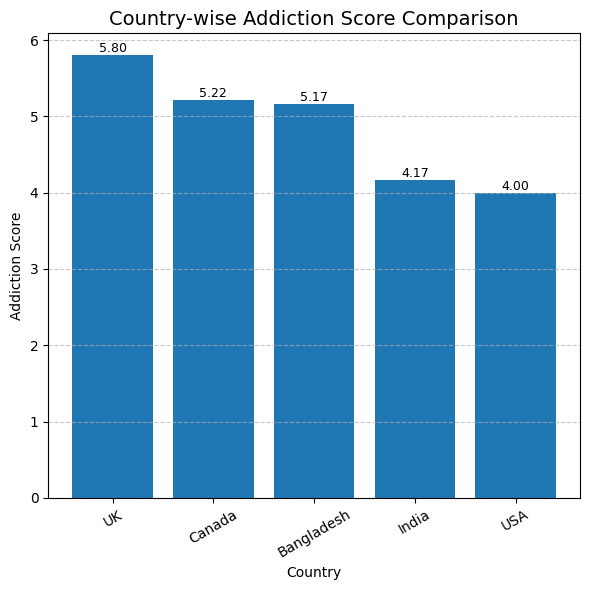

In [6]:
# Group by country
country_analysis = df.groupby('Country').agg({
    'Avg_Daily_Usage_Hours': 'mean',
    'Addicted_Score': 'mean',
    'Mental_Health_Score': 'mean'
})

# Sort by addiction score
country_analysis = country_analysis.sort_values(by='Addicted_Score')

print("\nCountry-wise Analysis:")
print(country_analysis)

# Create Risk Score (custom metric)
df['Risk_Score'] = (
    df['Avg_Daily_Usage_Hours'] * 0.4 +
    df['Addicted_Score'] * 0.3 +
    (10 - df['Mental_Health_Score']) * 0.3
)

# Country-wise risk
risk_country = df.groupby('Country')['Risk_Score'].mean().sort_values()

print("\nRisk Score by Country:")
print(risk_country)

import matplotlib.pyplot as plt

# Sort data (important for clean look)
country_analysis = country_analysis.sort_values(by='Addicted_Score', ascending=False)

plt.figure(figsize=(6,6))

bars = plt.bar(
    country_analysis.index,
    country_analysis['Addicted_Score']
)

# Titles
plt.title("Country-wise Addiction Score Comparison", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Addiction Score")

# Rotate labels for readability
plt.xticks(rotation=30)

# Grid for better clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars (VERY IMPORTANT)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


Age Group Analysis:
             Avg_Daily_Usage_Hours  Addicted_Score  Mental_Health_Score
Age_Group                                                              
Teen                      5.450000        4.500000             5.800000
Young Adult               5.015625        5.031250             6.531250
Adult                     4.895918        4.306122             6.285714
Mature                         NaN             NaN                  NaN


/tmp/ipykernel_579/2156630488.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby('Age_Group').agg({


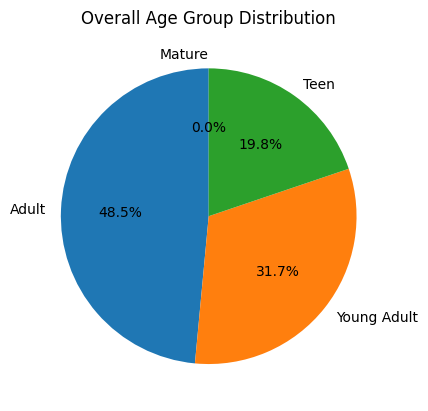

In [7]:
# Create age groups
bins = [15, 18, 21, 25, 30]
labels = ['Teen', 'Young Adult', 'Adult', 'Mature']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Group analysis
age_analysis = df.groupby('Age_Group').agg({
    'Avg_Daily_Usage_Hours': 'mean',
    'Addicted_Score': 'mean',
    'Mental_Health_Score': 'mean'
})

print("\nAge Group Analysis:")
print(age_analysis)

# Count number of people in each age group
age_counts = df['Age_Group'].value_counts()

# Plot pie chart
plt.figure()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Overall Age Group Distribution")
plt.show()

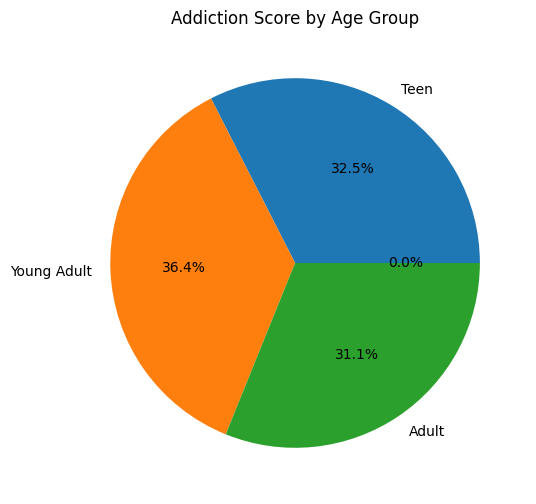

In [8]:
age_analysis['Addicted_Score'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Addiction Score by Age Group")
plt.ylabel("")
plt.show()

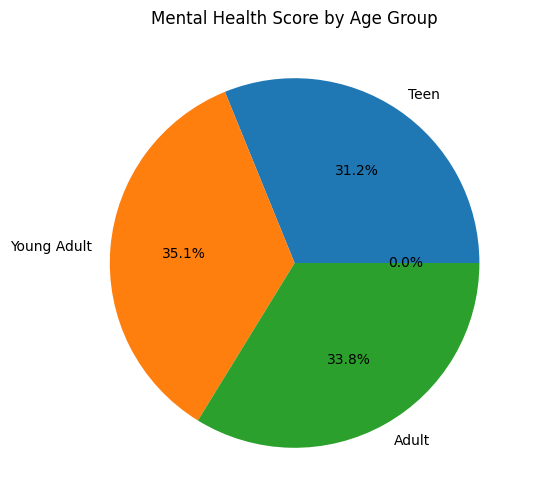

In [9]:
age_analysis['Mental_Health_Score'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Mental Health Score by Age Group")
plt.ylabel("")
plt.show()

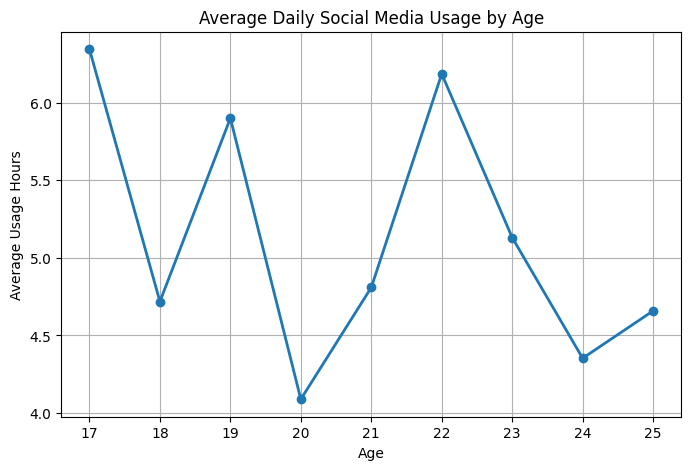

In [10]:
# ==============================
# LINE GRAPH - Average Usage by Age
# ==============================

age_usage = df.groupby('Age')['Avg_Daily_Usage_Hours'].mean()

plt.figure(figsize=(8,5))

plt.plot(
    age_usage.index,
    age_usage.values,
    marker='o',
    linewidth=2
)

plt.title("Average Daily Social Media Usage by Age")
plt.xlabel("Age")
plt.ylabel("Average Usage Hours")
plt.grid(True)

plt.show()

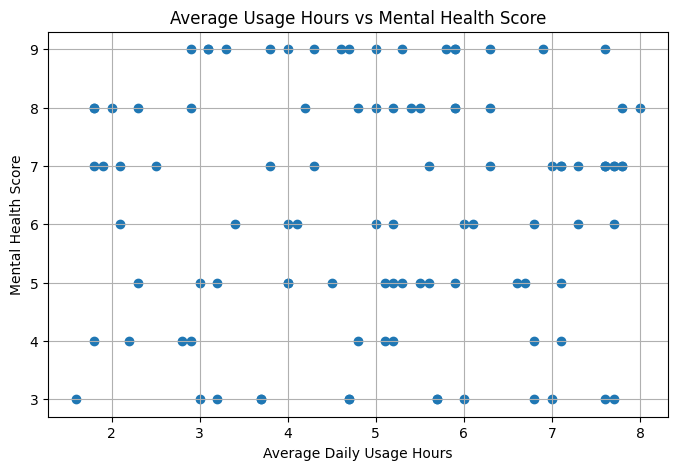

In [14]:
# ==============================
# SCATTER PLOT
# ==============================

plt.figure(figsize=(8,5))

plt.scatter(
    df['Avg_Daily_Usage_Hours'],
    df['Mental_Health_Score']
)

plt.title("Average Usage Hours vs Mental Health Score")
plt.xlabel("Average Daily Usage Hours")
plt.ylabel("Mental Health Score")

plt.grid(True)

plt.show()

In [11]:
# Categorize usage level
df['Usage_Level'] = pd.cut(
    df['Avg_Daily_Usage_Hours'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

# Show counts
print("\nUsage Level Distribution:")
print(df['Usage_Level'].value_counts())


Usage Level Distribution:
Usage_Level
Medium    51
High      31
Low       19
Name: count, dtype: int64


In [12]:
high_risk = df[
    (df['Avg_Daily_Usage_Hours'] > 6) &
    (df['Mental_Health_Score'] < 5)
]

print("\n🚨 High Risk Students:")
print(high_risk[['Country', 'Age', 'Avg_Daily_Usage_Hours', 'Mental_Health_Score']])


🚨 High Risk Students:
       Country  Age  Avg_Daily_Usage_Hours  Mental_Health_Score
21       India   22                    6.8                    3
23       India   17                    6.8                    4
52         USA   22                    7.1                    4
65  Bangladesh   21                    7.7                    3
66       India   24                    7.0                    3
80       India   19                    7.6                    3


In [13]:
print("="*50)
print("        IDEAL STUDENT HEALTH GUIDELINES")
print("="*50)

print("\n1. Screen Time Recommendation:")
print("   - Optimal Usage: 2 to 3 hours per day")
print("   - Rationale: Minimizes digital fatigue and addiction risk")

print("\n2. Sleep Recommendation:")
print("   - Ideal Duration: 7 to 8 hours per night")
print("   - Minimum Requirement: 6 hours")
print("   - Rationale: Supports cognitive function and mental stability")

print("\n3. Mental Health Benchmark:")
print("   - Desired Score: 8 to 10 (on a scale of 1–10)")
print("   - Interpretation: Indicates good psychological well-being")

print("\nConclusion:")
print("Maintaining balanced screen time along with adequate sleep")
print("contributes significantly to better mental health outcomes.")

print("="*50)
ideal_students = df[
    (df['Avg_Daily_Usage_Hours'] <= 3) &
    (df['Sleep_Hours_Per_Night'] >= 6) &
    (df['Mental_Health_Score'] >= 8)
]

print("Number of Ideal Healthy Students:", len(ideal_students))
ideal = ideal_students.head()

print("Ideal Students:")
print(ideal[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Affects_Academic_Performance']])

        IDEAL STUDENT HEALTH GUIDELINES

1. Screen Time Recommendation:
   - Optimal Usage: 2 to 3 hours per day
   - Rationale: Minimizes digital fatigue and addiction risk

2. Sleep Recommendation:
   - Ideal Duration: 7 to 8 hours per night
   - Minimum Requirement: 6 hours
   - Rationale: Supports cognitive function and mental stability

3. Mental Health Benchmark:
   - Desired Score: 8 to 10 (on a scale of 1–10)
   - Interpretation: Indicates good psychological well-being

Conclusion:
Maintaining balanced screen time along with adequate sleep
contributes significantly to better mental health outcomes.
Number of Ideal Healthy Students: 3
Ideal Students:
    Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  \
2                     1.8                    6.4                    8   
27                    2.9                    7.7                    8   
64                    1.8                    6.7                    8   

   Affects_Academic_Performance  
2      